/tmp/ipykernel_416/3905991573.py:35: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  persona_df = pd.DataFrame(persona).applymap(lambda x: level_map[x])


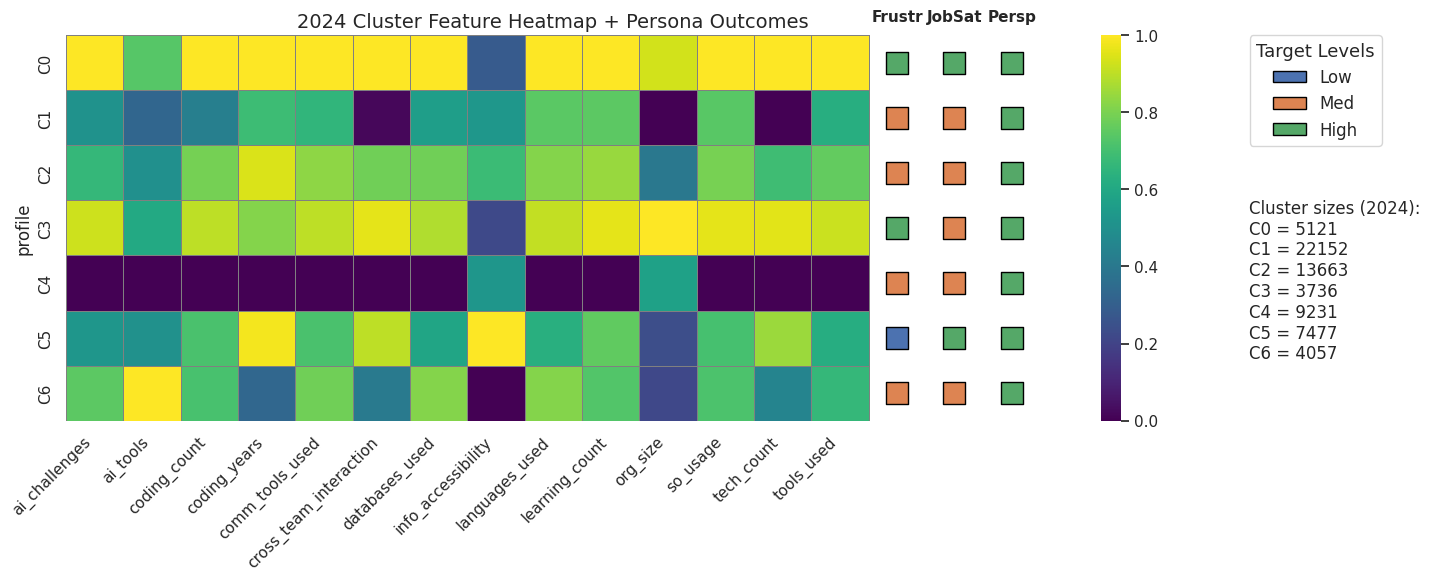

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as Patch

# === Load data ===
df = pd.read_csv("LPA_full_profile_summary_2024.csv")
cluster_col = "profile"

# === Detect continuous features automatically ===
feat_cols = [
    c for c in df.columns
    if c not in ['profile','size']
    and not c.endswith('class0')
    and not c.endswith('class1')
    and not c.endswith('class2')
]

# === Persona target classes ===
targets = {
    'Frustr': ['Frustration_class0','Frustration_class1','Frustration_class2'],
    'JobSat': ['JobSat_class0','JobSat_class1','JobSat_class2'],
    'Persp': ['JobPerspectiveClass_class0','JobPerspectiveClass_class1','JobPerspectiveClass_class2'],
}

level_map = {0:'Low',1:'Med',2:'High'}
level_colors = {'Low':'#4C72B0','Med':'#DD8452','High':'#55A868'}

# === Dominant persona per cluster ===
tmp = df.set_index(cluster_col)[sum(targets.values(), [])]
persona = {}
for t, cols in targets.items():
    persona[t] = tmp[cols].idxmax(axis=1).str[-1].astype(int)
persona_df = pd.DataFrame(persona).applymap(lambda x: level_map[x])

# === Cluster sizes ===
sizes = df.set_index(cluster_col)['size']

# === Normalize features (0-1 absolute scale) ===
feat = df.set_index(cluster_col)[feat_cols]
feat_norm = (feat - feat.min()) / (feat.max() - feat.min())

clusters = sorted(feat_norm.index.tolist())

# === Plot ===
fig, ax = plt.subplots(figsize=(14,6))
sns.set(style="white")

sns.heatmap(
    feat_norm.loc[clusters],
    cmap="viridis",
    linewidths=0.4,
    linecolor="gray",
    cbar=True,
    ax=ax
)

# Extend axis for persona squares
ax.set_xlim(0, len(feat_cols) + 3)

# === Add persona squares ===
for i, c in enumerate(clusters):
    for j, t in enumerate(['Frustr','JobSat','Persp']):
        lev = persona_df.loc[c, t]
        ax.scatter(
            len(feat_cols) + j + 0.5,
            i + 0.5,
            s=250,
            marker='s',
            color=level_colors[lev],
            edgecolor='black'
        )

# === Axis labeling ===
ax.set_xticks(np.arange(len(feat_cols)) + 0.5)
ax.set_xticklabels(feat_cols, rotation=45, ha='right')

ax.set_yticks(np.arange(len(clusters)) + 0.5)
ax.set_yticklabels([f"C{c}" for c in clusters])

# === Persona column headers ===
for j, t in enumerate(['Frustr','JobSat','Persp']):
    ax.text(
        len(feat_cols) + j + 0.5,
        -0.2,
        t,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# === Persona legend ===
legend_handles = [
    Patch.Patch(facecolor=color, edgecolor='black', label=lev)
    for lev, color in level_colors.items()
]
plt.legend(
    handles=legend_handles,
    title="Target Levels",
    bbox_to_anchor=(1.35, 1),
    borderaxespad=0,
    frameon=True,
    fontsize=12,        # legend labels size
    title_fontsize=13   # legend title size
)

# === Add cluster size legend ===
size_text = "Cluster sizes (2024):\n" + "\n".join(
    [f"C{c} = {sizes[c]}" for c in clusters]
)
plt.gcf().text(
    0.90, 0.65,
    size_text,
    fontsize=12,
    va='top',
    ha='left'
)

plt.title("2024 Cluster Feature Heatmap + Persona Outcomes", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_416/1706722409.py:35: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  persona_df = pd.DataFrame(persona).applymap(lambda x: level_map[x])


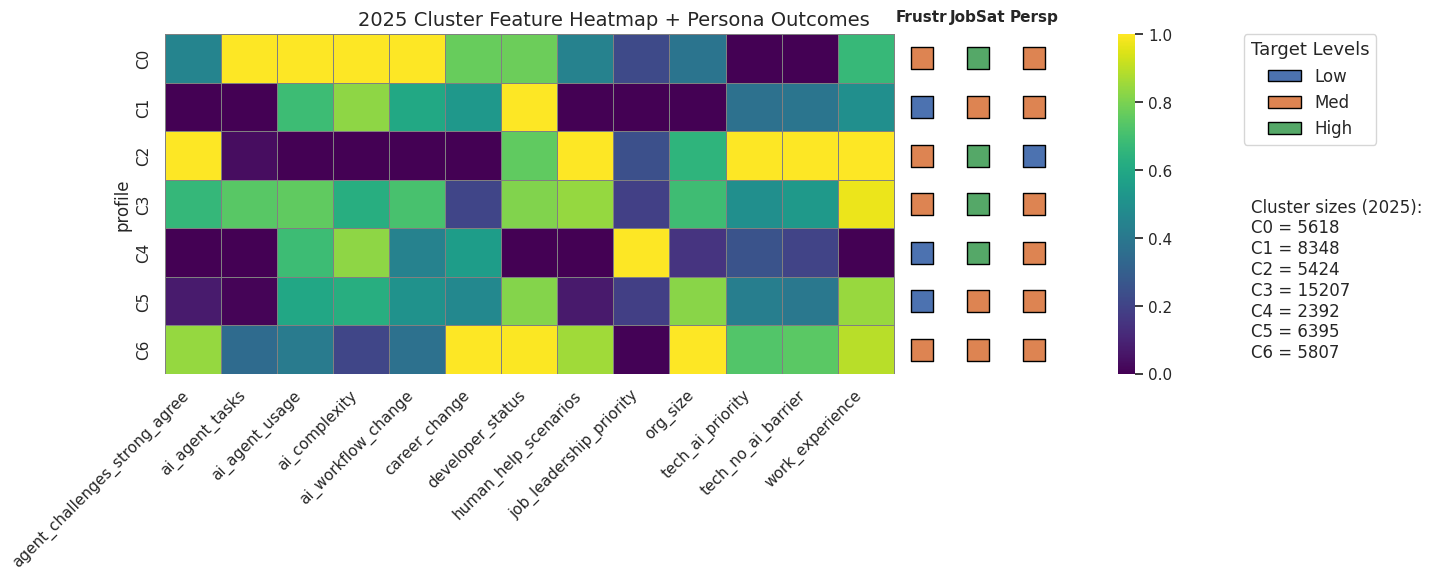

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as Patch

# === Load data ===
df = pd.read_csv("LPA_full_profile_summary2025.csv")
cluster_col = "profile"

# === Detect continuous features automatically ===
feat_cols = [
    c for c in df.columns
    if c not in ['profile','size']
    and not c.endswith('class0')
    and not c.endswith('class1')
    and not c.endswith('class2')
]

# === Persona target classes ===
targets = {
    'Frustr': ['Frustration_class0','Frustration_class1','Frustration_class2'],
    'JobSat': ['JobSat_class0','JobSat_class1','JobSat_class2'],
    'Persp': ['JobPerspectiveClass_class0','JobPerspectiveClass_class1','JobPerspectiveClass_class2'],
}

level_map = {0:'Low',1:'Med',2:'High'}
level_colors = {'Low':'#4C72B0','Med':'#DD8452','High':'#55A868'}

# === Dominant persona per cluster ===
tmp = df.set_index(cluster_col)[sum(targets.values(), [])]
persona = {}
for t, cols in targets.items():
    persona[t] = tmp[cols].idxmax(axis=1).str[-1].astype(int)
persona_df = pd.DataFrame(persona).applymap(lambda x: level_map[x])

# === Cluster sizes ===
sizes = df.set_index(cluster_col)['size']

# === Normalize features (0-1 absolute scale) ===
feat = df.set_index(cluster_col)[feat_cols]
feat_norm = (feat - feat.min()) / (feat.max() - feat.min())

clusters = sorted(feat_norm.index.tolist())

# === Plot ===
fig, ax = plt.subplots(figsize=(14,6))
sns.set(style="white")

sns.heatmap(
    feat_norm.loc[clusters],
    cmap="viridis",
    linewidths=0.4,
    linecolor="gray",
    cbar=True,
    ax=ax
)

# Extend axis for persona squares
ax.set_xlim(0, len(feat_cols) + 3)

# === Add persona squares ===
for i, c in enumerate(clusters):
    for j, t in enumerate(['Frustr','JobSat','Persp']):
        lev = persona_df.loc[c, t]
        ax.scatter(
            len(feat_cols) + j + 0.5,
            i + 0.5,
            s=250,
            marker='s',
            color=level_colors[lev],
            edgecolor='black'
        )

# === Axis labeling ===
ax.set_xticks(np.arange(len(feat_cols)) + 0.5)
ax.set_xticklabels(feat_cols, rotation=45, ha='right')

ax.set_yticks(np.arange(len(clusters)) + 0.5)
ax.set_yticklabels([f"C{c}" for c in clusters])

# === Persona column headers ===
for j, t in enumerate(['Frustr','JobSat','Persp']):
    ax.text(
        len(feat_cols) + j + 0.5,
        -0.2,
        t,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# === Persona legend ===
legend_handles = [
    Patch.Patch(facecolor=color, edgecolor='black', label=lev)
    for lev, color in level_colors.items()
]
plt.legend(
    handles=legend_handles,
    title="Target Levels",
    bbox_to_anchor=(1.35, 1),
    borderaxespad=0,
    frameon=True,
    fontsize=12,        # legend labels size
    title_fontsize=13   # legend title size
)

# === Add cluster size legend ===
size_text = "Cluster sizes (2025):\n" + "\n".join(
    [f"C{c} = {sizes[c]}" for c in clusters]
)
plt.gcf().text(
    0.90, 0.65,
    size_text,
    fontsize=12,
    va='top',
    ha='left'
)

plt.title("2025 Cluster Feature Heatmap + Persona Outcomes", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_416/2690608244.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  persona_df = pd.DataFrame(persona).applymap(lambda x: level_map[x])


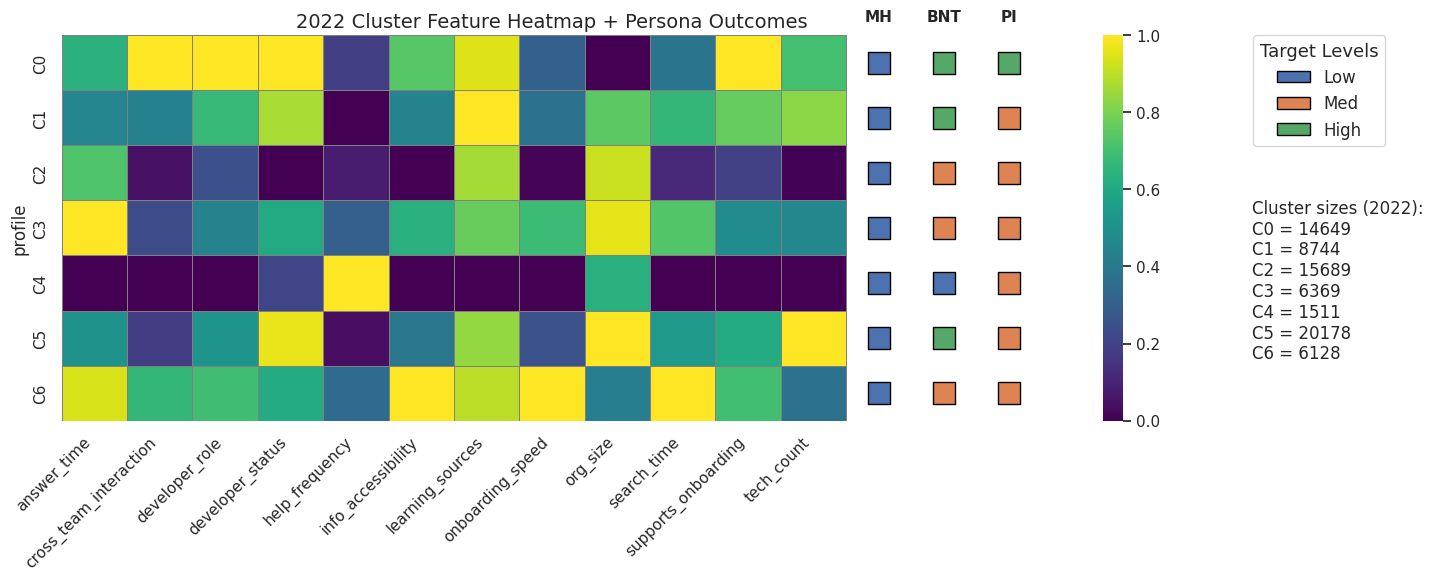

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as Patch

# === Load data ===
df = pd.read_csv("LPA_full_profile_summary_2022.csv")
cluster_col = "profile"

# === Detect continuous features automatically ===
feat_cols = [
    c for c in df.columns
    if c not in ['profile','size']
    and not c.endswith('class0')
    and not c.endswith('class1')
    and not c.endswith('class2')
]

# === Persona targets (2022) with short labels ===
targets = {
    'MH': [
        'MentalHealth_class0','MentalHealth_class1','MentalHealth_class2'
    ],
    'BNT': [
        'BuyNewTool_class0','BuyNewTool_class1','BuyNewTool_class2'
    ],
    'PI': [
        'PurchaseInfluence_class0','PurchaseInfluence_class1','PurchaseInfluence_class2'
    ]
}

level_map = {0:'Low',1:'Med',2:'High'}
level_colors = {'Low':'#4C72B0','Med':'#DD8452','High':'#55A868'}

# === Dominant persona per cluster ===
tmp = df.set_index(cluster_col)[sum(targets.values(), [])]
persona = {}
for t, cols in targets.items():
    persona[t] = tmp[cols].idxmax(axis=1).str[-1].astype(int)
persona_df = pd.DataFrame(persona).applymap(lambda x: level_map[x])

# === Cluster sizes ===
sizes = df.set_index(cluster_col)['size']

# === Normalize features (0-1 absolute scale) ===
feat = df.set_index(cluster_col)[feat_cols]
feat_norm = (feat - feat.min()) / (feat.max() - feat.min())

clusters = sorted(feat_norm.index.tolist())

# === Plot ===
fig, ax = plt.subplots(figsize=(14,6))
sns.set(style="white")

sns.heatmap(
    feat_norm.loc[clusters],
    cmap="viridis",
    linewidths=0.4,
    linecolor="gray",
    cbar=True,
    ax=ax
)

# Extend axis for persona squares
ax.set_xlim(0, len(feat_cols) + len(targets))

# === Add persona squares ===
shorts = list(targets.keys())
for i, c in enumerate(clusters):
    for j, t in enumerate(shorts):
        lev = persona_df.loc[c, t]
        ax.scatter(
            len(feat_cols) + j + 0.5,
            i + 0.5,
            s=250,
            marker='s',
            color=level_colors[lev],
            edgecolor='black'
        )

# === Axis labeling ===
ax.set_xticks(np.arange(len(feat_cols)) + 0.5)
ax.set_xticklabels(feat_cols, rotation=45, ha='right')

ax.set_yticks(np.arange(len(clusters)) + 0.5)
ax.set_yticklabels([f"C{c}" for c in clusters])

# === Persona headers (short forms) ===
for j, t in enumerate(shorts):
    ax.text(
        len(feat_cols) + j + 0.5,
        -0.2,
        t,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# === Persona legend ===
legend_handles = [
    Patch.Patch(facecolor=color, edgecolor='black', label=lev)
    for lev, color in level_colors.items()
]
plt.legend(
    handles=legend_handles,
    title="Target Levels",
    bbox_to_anchor=(1.35, 1),
    borderaxespad=0,
    frameon=True,
    fontsize=12,        # legend labels size
    title_fontsize=13   # legend title size
)


# === Cluster sizes ===
size_text = "Cluster sizes (2022):\n" + "\n".join(
    [f"C{c} = {sizes[c]}" for c in clusters]
)
plt.gcf().text(
    0.90, 0.65,
    size_text,
    fontsize=12,
    va='top',
    ha='left'
)

plt.title("2022 Cluster Feature Heatmap + Persona Outcomes", fontsize=14)
plt.tight_layout()
plt.show()
